In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
data=pd.read_csv(r"C:\Users\renus\OneDrive\Desktop\sentiment data analysis\IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [4]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [5]:
data.shape

(50000, 2)

In [6]:
data.columns

Index(['review', 'sentiment'], dtype='object')

In [7]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
data['sentiment'] = data['sentiment'].str.strip()

In [9]:
data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

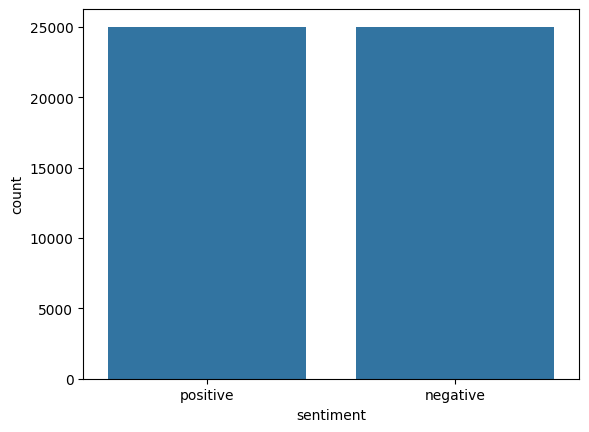

In [10]:
sns.countplot(x='sentiment',data=data)
plt.show()

In [11]:
import re
import nltk
from nltk.corpus import stopwords

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\renus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
#removing tag 
def remove_html(text):
    clean=re.compile('<.*?>')
    return re.sub(clean,'',text)

In [14]:
data['review']=data['review'].apply(remove_html)

In [15]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
#remove punchuvations and numbers
def remove_special(text):
    text=re.sub('[a-zA-z]','',text)
    return text

In [17]:
#lower case
data['review']=data['review'].str.lower()

In [18]:
data.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [19]:
#stop word removal
stop_word=set(stopwords.words('english'))

def remove_stopwords(text):
    words=text.split()
    words=[word for word in words if word not in stop_word]
    return " " .join(words)

In [20]:
#combine all cleaning words
def clean_text(text):
    text= re.sub('<.* ?>',' ',text)
    text=re.sub('[^a-zA-Z]', ' ', text)
    text=text.lower()
    words=text.split()
    words=[word for word in words if word not in stop_word]
    return " ".join(words)


In [21]:
data['clean_review']=data['review'].apply(clean_text)

In [22]:
data.head()

,review,sentiment,clean_review
0,one of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,a wonderful little production. the filming tec...,positive,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei love time money visually stunnin...


In [23]:
#feature extraction covert text into numbers 
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=5000)
x=vectorizer.fit_transform(data['clean_review'])

In [24]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})
y=data['sentiment']

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(
x,y,test_size=0.2,random_state=42
)

In [26]:
#A very good baseline model for sentiment analysis is Logistic Regression.
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
y_pred=model.predict(x_test)

In [28]:
from sklearn. metrics import accuracy_score
accuracy= accuracy_score(y_test,y_pred)
print(accuracy)

0.8922


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(x_train, y_train)

y_pred_nb = nb_model.predict(x_test)

In [31]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8554


In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

In [33]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8821


In [34]:
import pandas as pd
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8922
1          Naive Bayes    0.8554
2                  SVM    0.8821


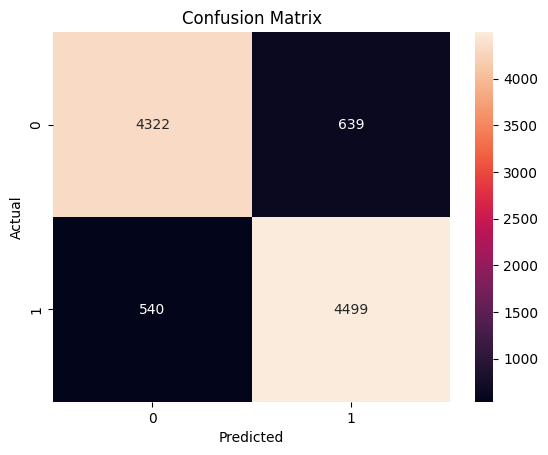

In [35]:
#confusion materix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [36]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



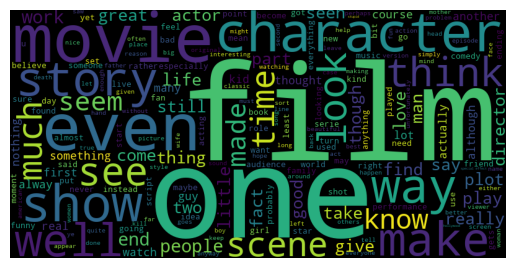

In [39]:
from wordcloud import WordCloud

text = " ".join(data['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [40]:
review = ["This movie was really amazing"]

review_vec = vectorizer.transform(review)

prediction = svm_model.predict(review_vec)

print(prediction)

[1]


In [41]:
import pickle

pickle.dump(svm_model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))